In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.pyplot import axis, title
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchsummary import summary

import polars as pl
import numpy as np

import copy

import matplotlib.pyplot as plt
from plotnine import *

pl.Config.set_tbl_cols(-1)

polars.config.Config

In [2]:
# create artificial datasets - Gaussian blurs with different widths

In [3]:
# from online pytorch lessons
nPerClass = 1000
imgSize   = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# the two widths (a.u.)
widths = [1.8,2.4]

# initialize tensors containing images and labels
images = torch.zeros(2*nPerClass,1,imgSize,imgSize)
labels = torch.zeros(2*nPerClass)

for i in range(2*nPerClass):

  # create the gaussian with random centers
  ro = 2*np.random.randn(2) # ro = random offset
  G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / (2*widths[i%2]**2) )

  # and add noise
  G  = G + np.random.randn(imgSize,imgSize)/5

  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
  labels[i] = i%2

labels = labels[:,None]

In [4]:
labels[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

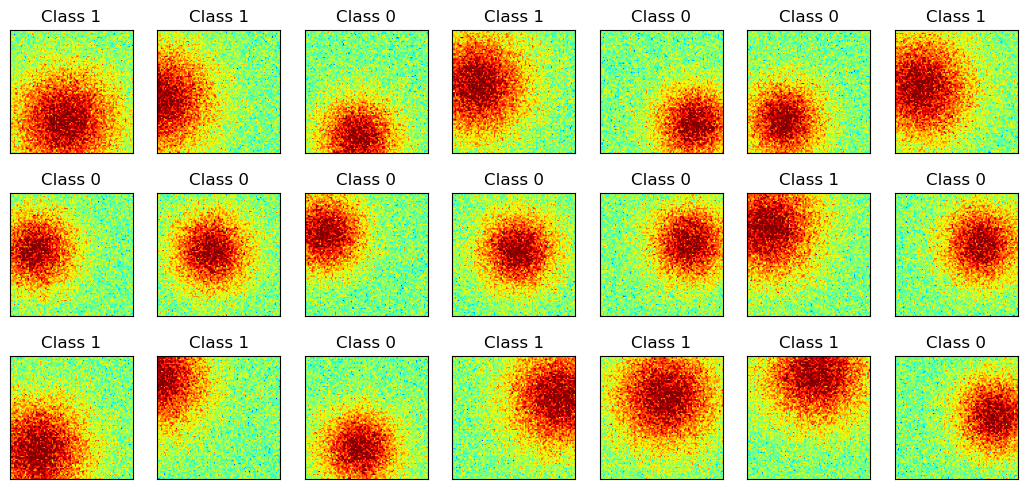

In [5]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(2*nPerClass)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_title('Class %s'%int(labels[whichpic].item()))
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

In [6]:
# prepare the data with scikitlearn
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.1, random_state=42)

In [7]:
# convert to Pytroch Dataset
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

# convert to data loader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [8]:
images.shape

torch.Size([2000, 1, 91, 91])

In [9]:
# create the DL model
class gaussNet(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()

        # activation map
        activation_map = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'leakyrelu': nn.LeakyReLU
        }

        # get the activation
        act_class = activation_map.get(activation.lower(), nn.ReLU)
        self.activation = act_class()

        # create the conv1
        self.conv1 = nn.Conv2d(
            in_channels=1, # the number of layersin the input
            out_channels=6, # the number of different filters (feature maps) the network learns
            kernel_size=3, # the size of the window (a 3 x 3) square
            padding=1 # add 1 pixel border around the image
        )
        # output_size: (91+2*1-3)/1 + 1 = 91
        # post pooling:  91/2 =  45

        # create conv2
        self.conv2 = nn.Conv2d(6, 4, 3, padding=1)
        # output size: (45 + 2 * 1 -3)/1 +1 = 45
        # post pooling: 45/2 = 22

        # create the fully-connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(22*22*4, 50),
            act_class(),
            nn.Linear(50,1)
        )

    def forward(self, x):
        # first conv-pool set
        conv1act = self.activation(self.conv1(x))
        x = F.avg_pool2d(conv1act, (2, 2))

        # second conv-pool set
        conv2act = self.activation(self.conv2(x))
        x = F.avg_pool2d(conv2act, (2, 2))

        # Flatten
        x = x.view(x.shape[0], -1)

        # Fully connected
        x = self.fc_layers(x)

        return x, conv1act, conv2act

In [10]:
# test the model
gaussNet()

gaussNet(
  (activation): ReLU()
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc_layers): Sequential(
    (0): Linear(in_features=1936, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [11]:
def create_gauss_system(
        activation='relu',
        optimizer_type='adam',
        learning_rate=0.001,
):
    # 1. Instantiate the model object only
    model = gaussNet(activation=activation)

    # 2. Loss function
    # MSELoss is usually used for regression, or
    # BCEWithLogitsLoss for binary classification.
    loss_func = nn.BCEWithLogitsLoss()

    # 3. Create the optimizer
    optimizer_map = {
        'adam': torch.optim.Adam,
        'sgd': torch.optim.SGD,
        'rmsprop': torch.optim.RMSprop
    }

    opt_class = optimizer_map.get(optimizer_type.lower(), torch.optim.Adam)

    # We pass the model parameters so the optimizer knows what to update
    optimizer = opt_class(model.parameters(), lr=learning_rate)

    return model, loss_func, optimizer

In [12]:
# 1. Initialize the system
model, loss_func, optimizer = create_gauss_system(
    activation='relu',
    optimizer_type='adam',
    learning_rate=0.001
)

# 2. Get one batch
X, y = next(iter(train_loader))

# 3. Forward pass: Pass X into the model
yHat, featuremap1, featuremap2 = model(X)

# 4. Calculate Loss
loss = loss_func(yHat, y.float())

print(f"loss value: {loss.item()}")
print(f"Feature map 1 shape: {featuremap1.shape}") # Expect [batch, 6, 91, 91]



loss value: 0.6792914271354675
Feature map 1 shape: torch.Size([32, 6, 91, 91])


In [13]:
# count the total number of parameters in the model
summary(model, (1, imgSize, imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
            Conv2d-3            [-1, 4, 45, 45]             220
              ReLU-4            [-1, 4, 45, 45]               0
            Linear-5                   [-1, 50]          96,850
              ReLU-6                   [-1, 50]               0
            Linear-7                    [-1, 1]              51
Total params: 97,181
Trainable params: 97,181
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 0.88
Params size (MB): 0.37
Estimated Total Size (MB): 1.28
----------------------------------------------------------------


In [14]:
# create a function that trains the model
def train_model_func(
        numepochs=100,
        train_loader=train_loader,
        test_loader=test_loader,

):
    training_progress = pl.DataFrame(
        schema=[
            ('iteration', pl.Float64),
            ('epoch', pl.Int64),
            ('epoch_lr', pl.Float64),
            ('train_loss', pl.Float64),
            ('train_acc', pl.Float64),
            ('test_loss', pl.Float64),
            ('test_acc', pl.Float64)
        ]
    )

    iteration = 0

    # create the model
    model, loss_func, optimizer = create_gauss_system(
        activation='relu',
        optimizer_type='adam',
        learning_rate=0.001
    )

    # set patience to stop when achieve convergence
    patience =  15
    best_loss = float('inf')
    no_improve_count = 0
    best_model = None

    # start the trainingloop
    for epoch in range(numepochs):
        model.train()
        # initialize the train loss and num batches
        epoch_train_loss = 0
        epoch_train_acc = 0
        train_batches = 0
        for inputs, targets in train_loader:
            yHat_train, featuremap1, featuremap2 = model(inputs)
            loss_train = loss_func(yHat_train, targets.view(-1, 1).float())
            # backprop
            optimizer.zero_grad()
            loss_train.backward()
            optimizer.step()
            # evaluate the training data
            train_predictions = (yHat_train > 0).float()
            train_matches = (train_predictions == targets.view(-1, 1)).float()
            train_acc = 100 * torch.mean(train_matches)
            # append the loss and accuracy
            epoch_train_loss += loss_train.item()
            epoch_train_acc += train_acc.item()

            train_batches += 1
            iteration += 1

        # update the learning rate per epoch
        current_lrs = optimizer.param_groups[0]['lr']

        # get the average training loss and accuracy
        avg_train_loss = epoch_train_loss / train_batches
        avg_train_acc = epoch_train_acc / train_batches

        # now we evaluate the test loader
        model.eval()
        epoch_test_loss = 0
        epoch_test_acc = 0
        test_batches = 0
        with torch.no_grad():
            for inputs_test, targets_test in test_loader:
                yHat_test, test_featuremap1, test_featuremap2 = model(inputs_test)
                loss_test = loss_func(yHat_test, targets_test.view(-1, 1).float())
                # get the test accurarcy
                test_preds = (yHat_test > 0).float()
                test_matches = (test_preds == targets_test.view(-1, 1)).float()
                test_acc = 100 * torch.mean(test_matches)

                epoch_test_loss += loss_test.item()
                epoch_test_acc += test_acc.item()

                test_batches += 1
        avg_test_loss = epoch_test_loss / test_batches
        avg_test_acc = epoch_test_acc / test_batches

        # create new row to annotate data
        new_row = pl.DataFrame([{
            'iteration' : float(iteration),
            'epoch' : int(epoch),
            'epoch_lr' : float(current_lrs),
            'train_loss' : avg_train_loss,
            'train_acc' : avg_train_acc,
            'test_loss' : avg_test_loss,
            'test_acc' : avg_test_acc,

        }])

        # concat the new row into the dataframe
        training_progress = pl.concat([training_progress, new_row])

        # early stopping logic
        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            no_improve_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            no_improve_count += 1

        # check early stopping condition
        if no_improve_count >= patience or epoch > 20:
            print(f"Early stopping at epoch {epoch}")
            if best_model is not None: # Check if best_model exists
                model.load_state_dict(best_model)
            break

    return training_progress, model, best_loss


In [15]:
# Run the model
training_progress, model, best_loss = train_model_func(
        numepochs=100,
        train_loader=train_loader,
        test_loader=test_loader,
)

Early stopping at epoch 21


In [16]:
# inspect the data
training_progress.head()

iteration,epoch,epoch_lr,train_loss,train_acc,test_loss,test_acc
f64,i64,f64,f64,f64,f64,f64
56.0,0,0.001,0.524607,75.78125,0.311152,94.0
112.0,1,0.001,0.208988,94.53125,0.19195,94.5
168.0,2,0.001,0.129846,95.982143,0.163464,93.0
224.0,3,0.001,0.103031,96.261161,0.121804,96.0
280.0,4,0.001,0.075786,97.65625,0.107009,96.5


In [17]:
p1 = (
    ggplot(training_progress, aes(x='epoch'))
    + geom_point(aes(y='train_acc', color='"train_acc"'))
    + geom_line(aes(y='train_acc', color='"train_acc"'))
    + geom_point(aes(y='test_acc', color='"test_acc"'))
    + geom_line(aes(y='test_acc', color='"test_acc"'))
    + geom_hline(
        aes(yintercept=98.5, linetype='"Best Test Performance"'),
        color='grey',
        size=0.5,
    )
    + scale_linetype_manual(
        values={"Best Test Performance": "dashed"}
    )
    + annotate(
        'text',
        x=25, y=98.5,
        ha='right', va='top',
        label='98.5%'
    )
    + theme_minimal()
    + theme(legend_title=element_blank(), legend_position='none',)
    + labs(
        title='Model Accuracy',
        x='Epoch',
        y='Accuracy (%)',
        tag='A',
    )

)


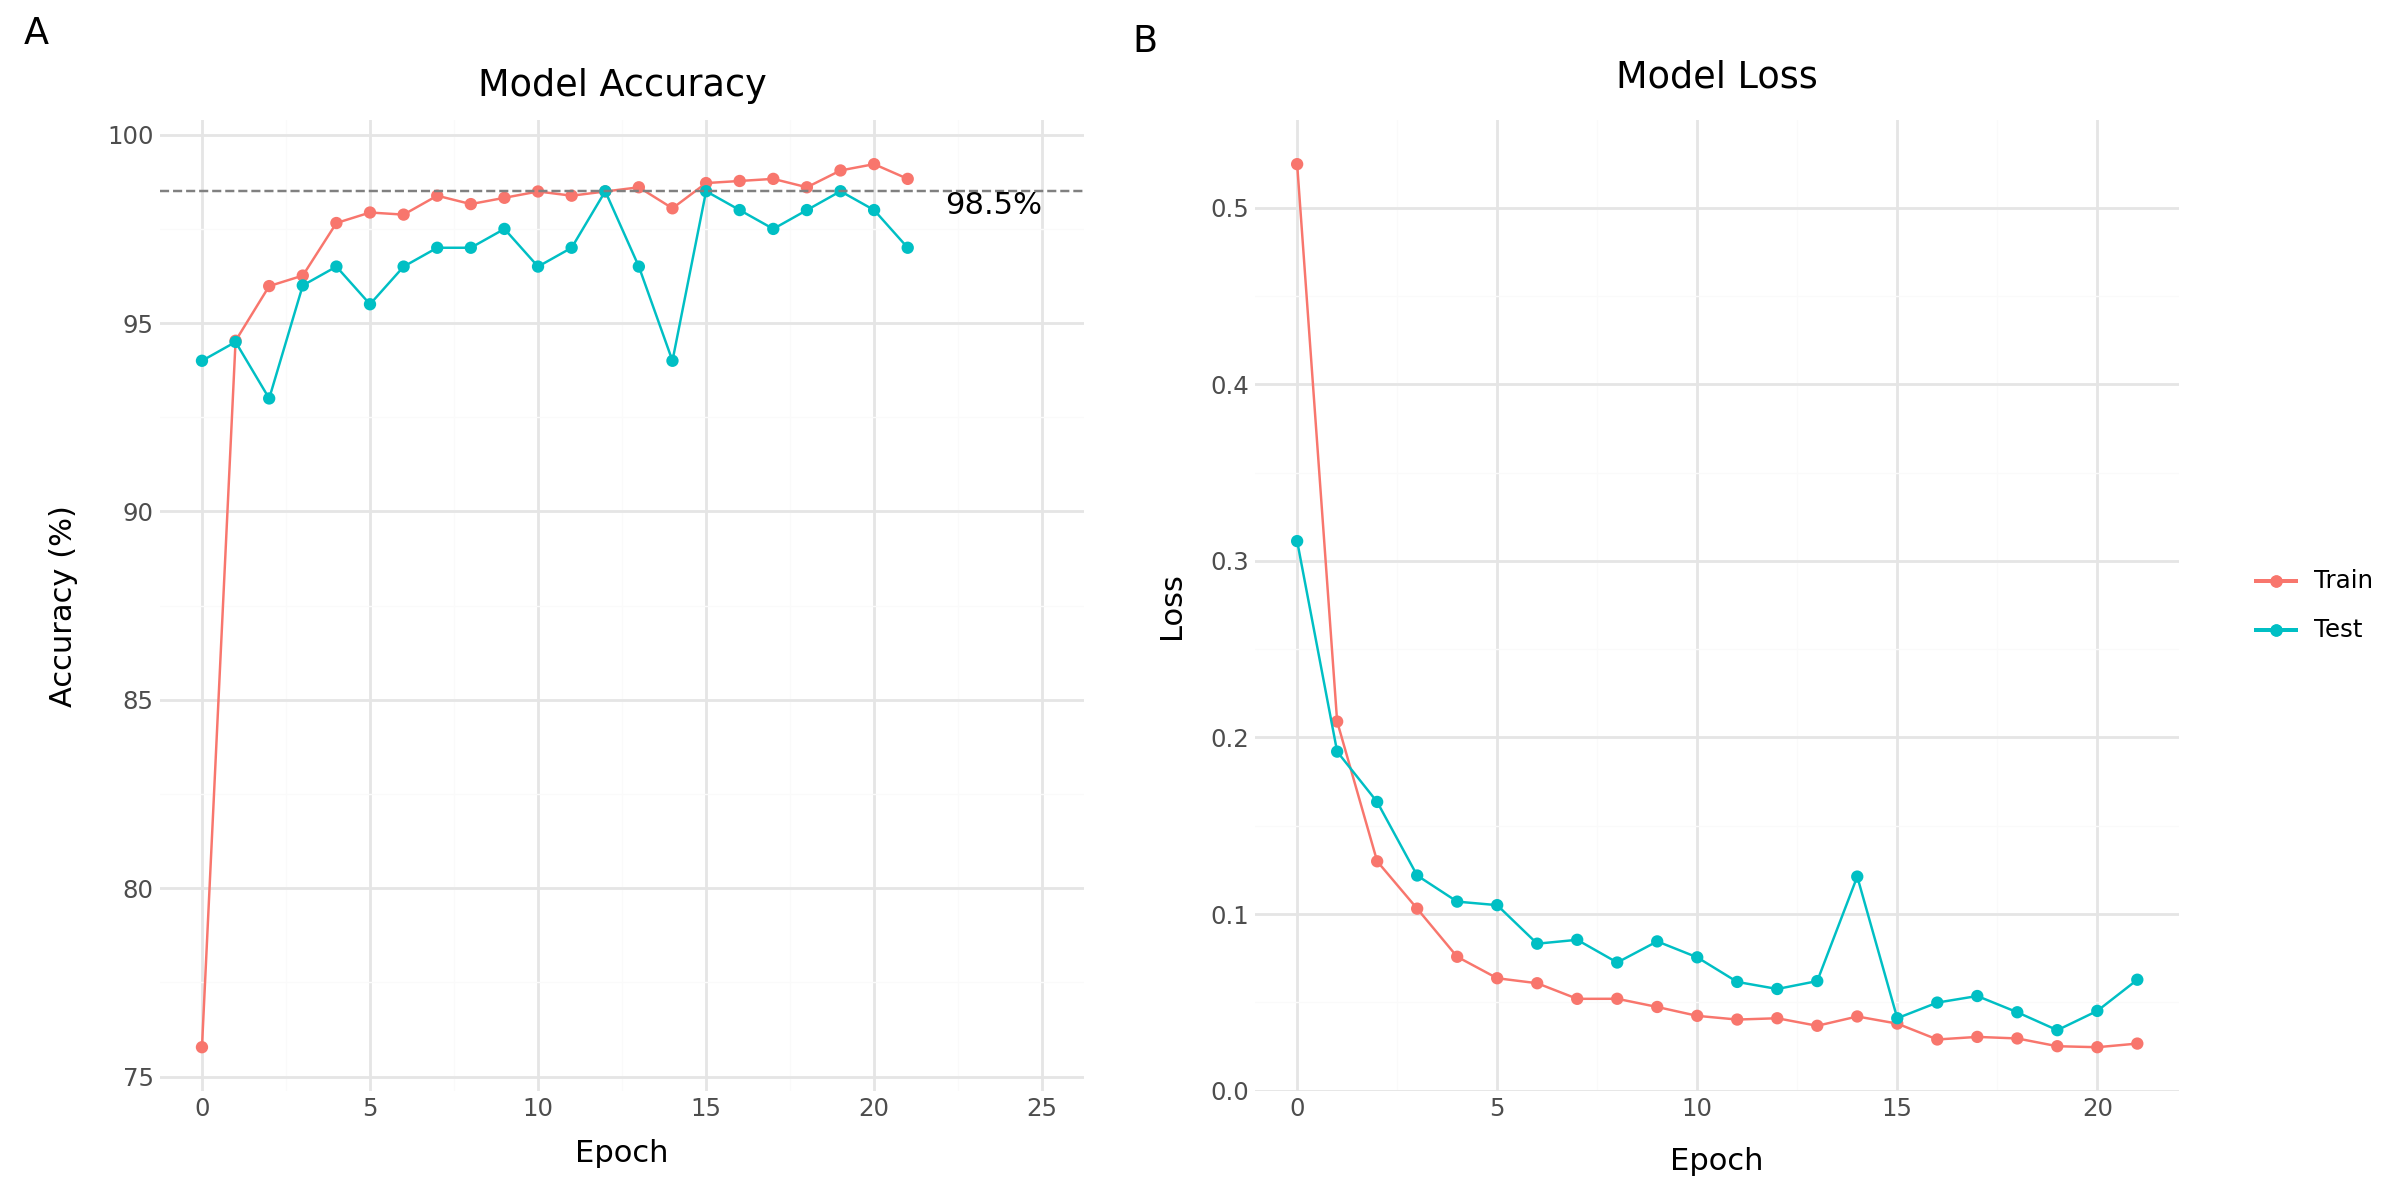

In [18]:
p2 = (
    ggplot(training_progress, aes(x='epoch'))
    + geom_point(aes(y='train_loss', color='"Train"'))
    + geom_line(aes(y='train_loss', color='"Train"'))
    + geom_point(aes(y='test_loss', color='"Test"'))
    + geom_line(aes(y='test_loss', color='"Test"'))
    + theme_minimal()
    + theme(legend_title=element_blank(), figure_size=(12, 6))
    + labs(
        title='Model Loss',
        x='Epoch',
        y='Loss',
        tag='B',
    )

)

(p1 | p2)

In [19]:
ranked_results = (
    training_progress
    # Calculate the gap between train and test (Overfitting check)
    .with_columns(
        gen_gap = (pl.col("train_acc") - pl.col("test_acc")).abs()
    )
    # Sort by highest test accuracy, then by lowest gap
    .sort(["test_acc", "gen_gap"], descending=[True, False])
    # Use selectors to pick columns cleanly
    .select(
        "epoch",
        pl.selectors.contains("acc"),
        "gen_gap"
    )
    .head(5)
)

print(ranked_results)

shape: (5, 4)
┌───────┬───────────┬──────────┬──────────┐
│ epoch ┆ train_acc ┆ test_acc ┆ gen_gap  │
│ ---   ┆ ---       ┆ ---      ┆ ---      │
│ i64   ┆ f64       ┆ f64      ┆ f64      │
╞═══════╪═══════════╪══════════╪══════════╡
│ 12    ┆ 98.493304 ┆ 98.5     ┆ 0.006696 │
│ 15    ┆ 98.716518 ┆ 98.5     ┆ 0.216518 │
│ 19    ┆ 99.051339 ┆ 98.5     ┆ 0.551339 │
│ 18    ┆ 98.604911 ┆ 98.0     ┆ 0.604911 │
│ 16    ┆ 98.772321 ┆ 98.0     ┆ 0.772321 │
└───────┴───────────┴──────────┴──────────┘


In [20]:
featuremap1.shape

torch.Size([32, 6, 91, 91])

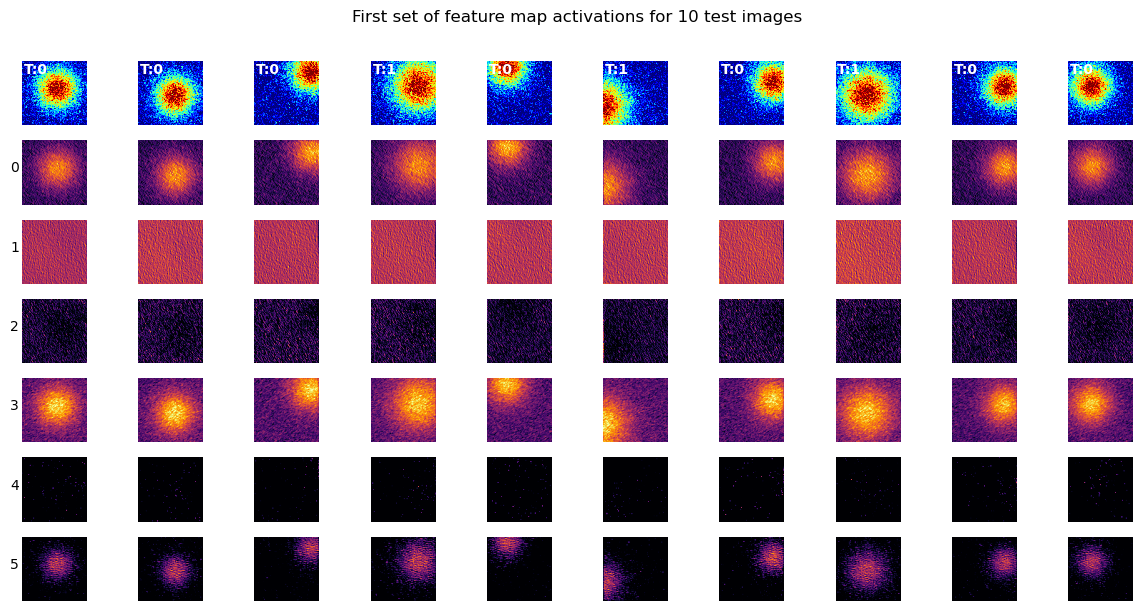

In [21]:
# feature maps from the conv1 layer
fig,axs = plt.subplots(7,10,figsize=(12,6))

for pici in range(10):

  # show the original picture
  # pici is the number of image
  # 0 is the first channel
  img = X[pici,0,:,:].detach()
  # 0 to show at the first row
  axs[0,pici].imshow(img,cmap='jet',vmin=0,vmax=1)
  axs[0,pici].axis('off')
  axs[0,pici].text(2,2,'T:%s'%int(y[pici].item()),ha='left',va='top',color='w',fontweight='bold')

  for feati in range(6):
    # extract the feature map from this image
    # remember the dimensions has [batch, channel, height, width]
    # +1 is starting from from the second row and downward
    # vmax=torch.max(img)*.9 incrasing the contrast
    img = featuremap1[pici,feati,:,:].detach()
    axs[feati+1,pici].imshow(img,cmap='inferno',vmin=0,vmax=torch.max(img)*.9)
    axs[feati+1,pici].axis('off')
    axs[feati+1,pici].text(-5,45,feati,ha='right') if pici==0 else None


plt.suptitle('First set of feature map activations for 10 test images',x=.5,y=1.01)
plt.tight_layout()
plt.show()

torch.Size([32, 4, 45, 45])


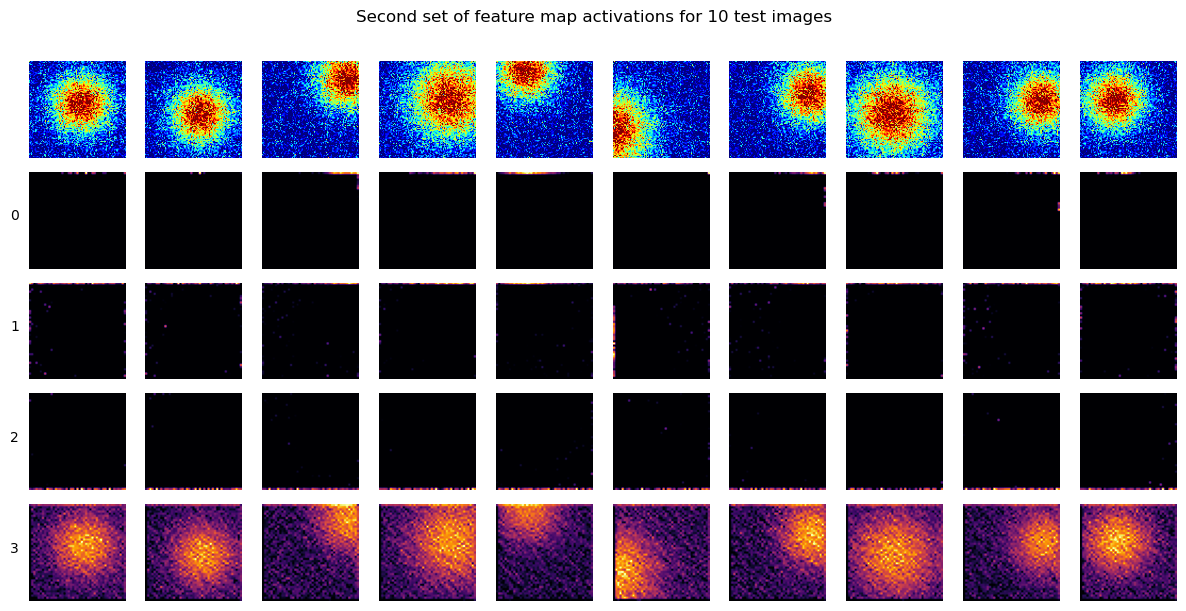

In [22]:
# repeat for the 2nd feature map
print(featuremap2.shape)

fig, axs = plt.subplots(5, 10, figsize=(12, 6))

for pici in range(10):
    # show the original image
    img = X[pici, 0, :, :].detach()
    # plot on the first row
    axs[0, pici].imshow(img, cmap='jet', vmin=0, vmax=1)
    axs[0, pici].axis('off')

    for feati in range(4):
        img = featuremap2[pici, feati, :, :].detach()
        # plot on the second row
        img = featuremap2[pici,feati,:,:].detach()
        axs[feati+1,pici].imshow(img,cmap='inferno',vmin=0,vmax=torch.max(img)*.9)
        axs[feati+1,pici].axis('off')
        axs[feati+1,pici].text(-5,22,feati,ha='right') if pici==0 else None

plt.suptitle('Second set of feature map activations for 10 test images',x=.5,y=1.01)
plt.tight_layout()
plt.show()

In [23]:
def get_tidy_correlations(featmap):
    """Reshapes feature maps and calculates correlations in a tidy format."""
    # n_stim: Number of images (stimuli) in batch
    # n_maps: Number of filters/kernels in the layer
    # h, w: the height and width of each feature map
    n_stim, n_maps, h, w = featmap.shape
    # Flatten pixels: (Stimulus, Maps, Pixels)
    # it keeps the first two dimensions but collapse the 2D image pixels (h x w) into a single long vector
    # instead of a stack of images now we have a list of vectors that is necessary because np.corrcoef expects vectors not 2D grids
    flat = featmap.view(n_stim, n_maps, -1).detach().cpu().numpy()

    rows = []
    # loop lok at an image at a time
    # flat[i] is a matrix of shape (nmaps, pixels)
    # calculates how similar each filter's output is to every othe rfilter's output for the specific image.
    for i in range(n_stim):
        c_mat = np.corrcoef(flat[i])
        # Get upper triangle (excluding diagonal)
        tri_rows, tri_cols = np.triu_indices(n_maps, k=1)
        for r, c, val in zip(tri_rows, tri_cols, c_mat[tri_rows, tri_cols]):
            rows.append({
                "stimulus": i,
                "pair": f"{r}-{c}",
                "correlation": val,
                "map_a": r,
                "map_b": c
            })
    return pl.DataFrame(rows)

# Generate the data
df_corr = get_tidy_correlations(featuremap2)

In [24]:
df_corr

stimulus,pair,correlation,map_a,map_b
i64,str,f64,i64,i64
0,"""0-1""",0.345821,0,1
0,"""0-2""",-0.008366,0,2
0,"""0-3""",0.065755,0,3
0,"""1-2""",-0.016605,1,2
0,"""1-3""",0.019141,1,3
…,…,…,…,…
31,"""0-2""",-0.018399,0,2
31,"""0-3""",0.374963,0,3
31,"""1-2""",-0.021797,1,2


In [25]:
# Calculate average correlation per pair
df_avg = df_corr.group_by(['map_a', 'map_b']).agg(pl.col('correlation').mean())

df_avg

map_a,map_b,correlation
i64,i64,f64
1,3,0.090801
1,2,-0.019081
2,3,-0.180425
0,1,0.513187
0,2,-0.009783
0,3,0.118077


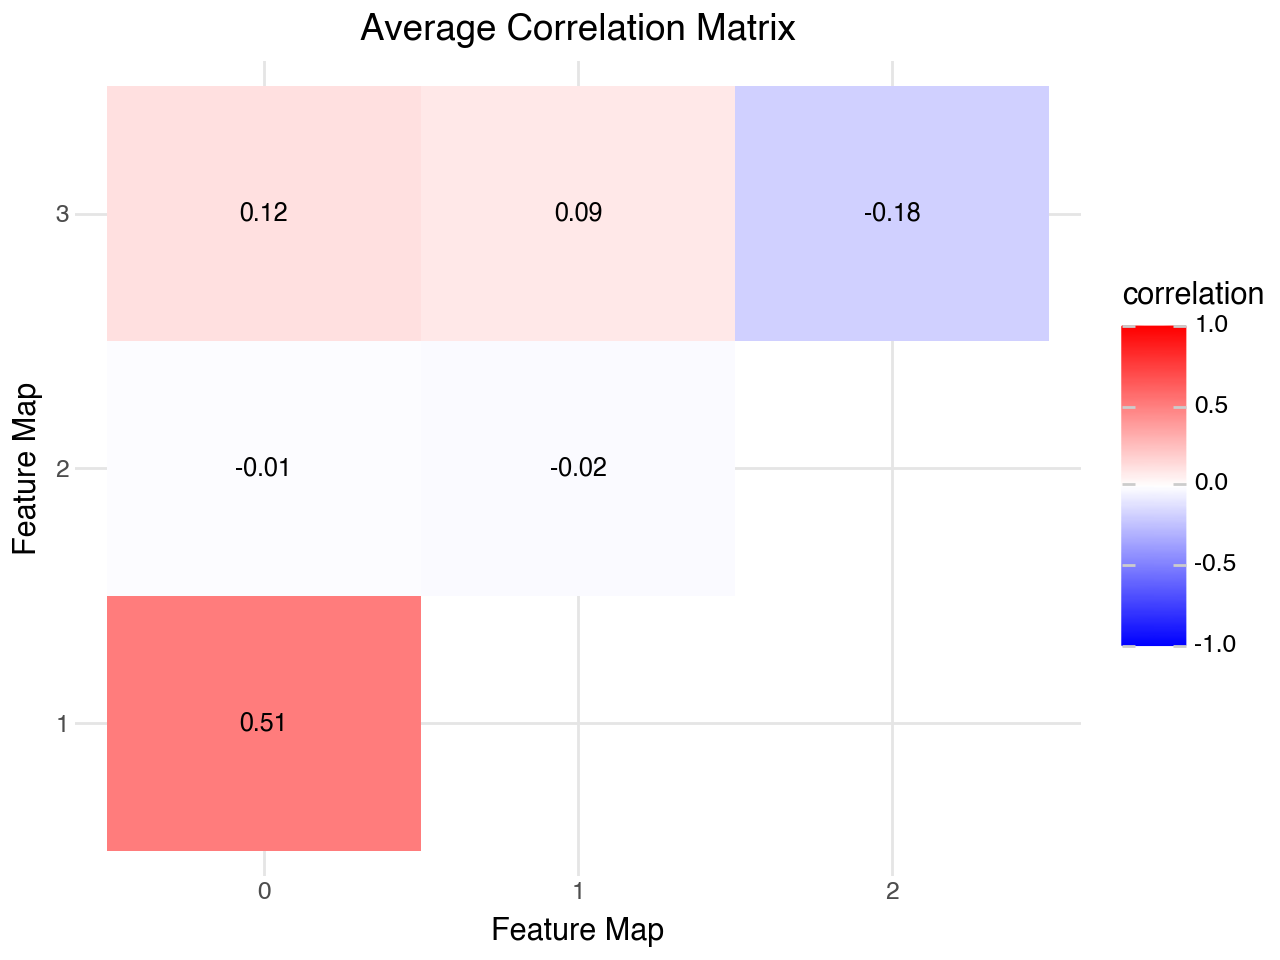

In [34]:
(
    ggplot(df_avg, aes(x='factor(map_a)', y='factor(map_b)', fill='correlation'))
    + geom_tile()
    + geom_text(aes(label=np.round(df_avg['correlation'], 2)), size=9)
    + scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
    + labs(title="Average Correlation Matrix", x="Feature Map", y="Feature Map")
    + theme_minimal()
)

In [27]:
# get the correlation of feature map 1
df_cor_featuremap1 = get_tidy_correlations(featuremap1)

df_cor_featuremap1

stimulus,pair,correlation,map_a,map_b
i64,str,f64,i64,i64
0,"""0-1""",-0.126332,0,1
0,"""0-2""",0.110585,0,2
0,"""0-3""",0.793123,0,3
0,"""0-4""",-0.009223,0,4
0,"""0-5""",0.587575,0,5
…,…,…,…,…
31,"""2-4""",-0.043719,2,4
31,"""2-5""",-0.104751,2,5
31,"""3-4""",0.031247,3,4


In [28]:
# groupby them tohether
df_avg_featuremap1 = (
    df_cor_featuremap1
    .group_by(['map_a', 'map_b'])
    .agg(pl.col('correlation').mean())
)

df_avg_featuremap1

map_a,map_b,correlation
i64,i64,f64
0,1,-0.119884
1,3,0.028058
1,4,-0.009486
4,5,0.040914
0,3,0.799199
…,…,…
3,5,0.532948
2,5,-0.098754
3,4,0.046846


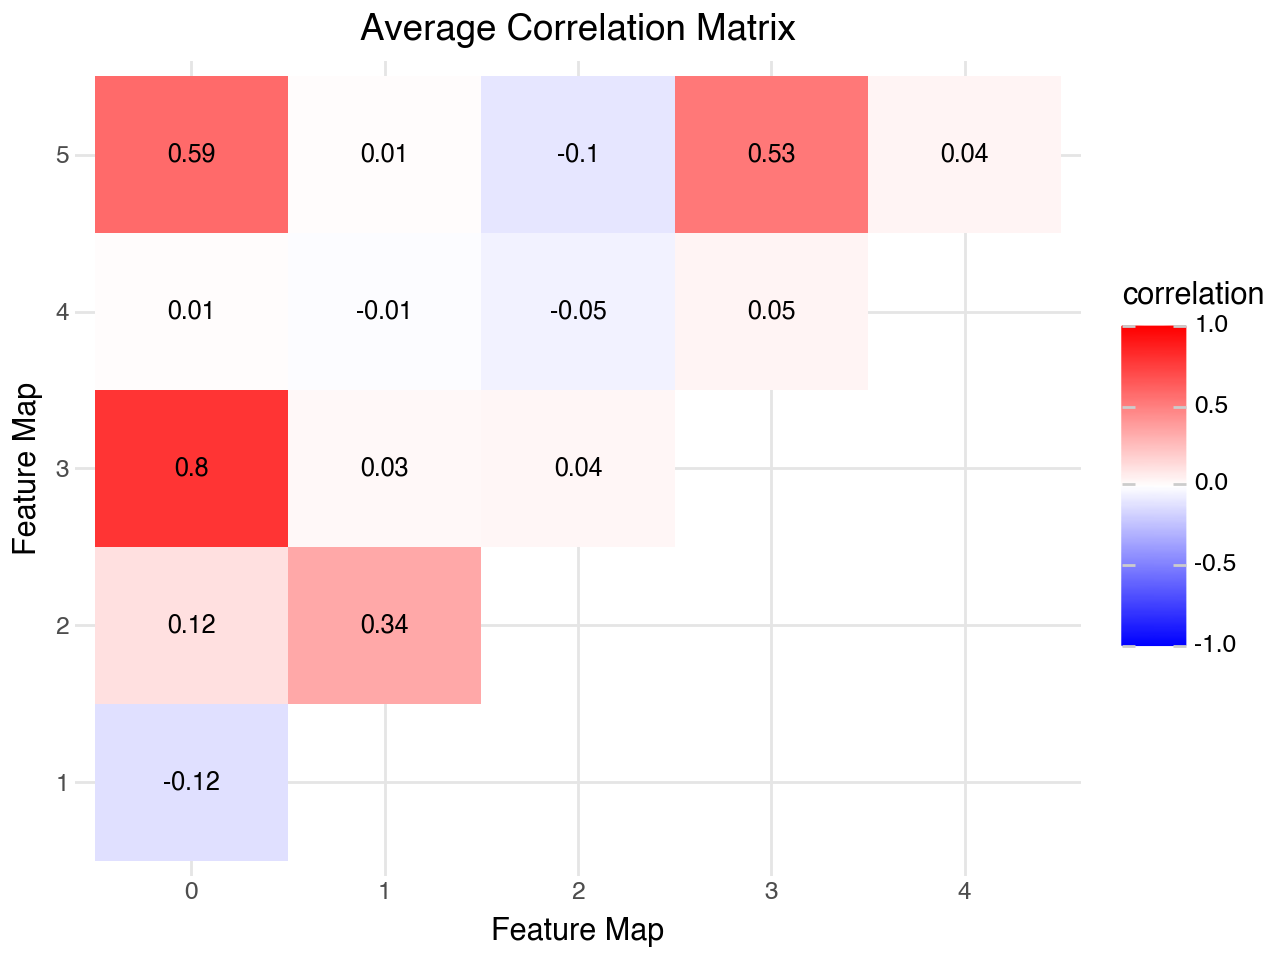

In [33]:
(
    ggplot(df_avg_featuremap1, aes(x='factor(map_a)', y='factor(map_b)', fill='correlation'))
    + geom_tile()
    + geom_text(aes(label=np.round(df_avg_featuremap1['correlation'], 2)), size=9)
    + scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
    + labs(title="Average Correlation Matrix", x="Feature Map", y="Feature Map")
    + theme_minimal()
)

In [35]:
!jupyter nbconvert --to html GaussClassFeatures-Polars.ipynb

[NbConvertApp] Converting notebook GaussClassFeatures-Polars.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('jetTransient' was unexpected)

Failed validating 'additionalProperties' in display_data:

On instance['cells'][4]['outputs'][0]:
{'data': {'image/png': 'iVBORw0KGgoAAAANSUhEUgAABAMAAAHpCAYAAAD3WfVtAAAAOXRFWHRTb2Z0d2Fy...',
          'text/plain': '<Figure size 1300x600 with 21 Axes>'},
 'jetTransient': {'display_id': None},
 'metadata': {},
 'output_type': 'display_data'}
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 3112017 bytes to GaussClassFeatures-Polars.html
